# Блок 1 — Подготовка данных

Загрузка, очистка и аугментация датасетов для обучения.

## Что происходит в этом блоке

1. Загружаем данные из 8+ источников (GoEmotions RU, CEDR, Izard, Dusha, BRIGHTER, Aniemore, RuReviews, RuSentiTweet)
2. Балансируем классы (MAX_PER_CLASS = 15k)
3. Аугментируем редкие классы (disgust, fear, anger) через rut5 + back-translation
4. Сохраняем на диск для блока 02

> **Предобработка**: только базовая очистка текста (URL, HTML, whitespace).
> Лемматизацию и стоп-слова не убираем — трансформеры обучены на живой морфологии
> и справляются с ней сами. Лемматизация снижает качество на 2-5% F1.

In [1]:
import sys, os, gc

PROJECT_ROOT = '/kaggle/input/datasets/inexyy/se-analysis' if os.path.exists('/kaggle') else os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

WORKING_DIR = '/kaggle/working' if os.path.exists('/kaggle') else '../results'
os.makedirs(WORKING_DIR, exist_ok=True)

import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_from_disk, Dataset, DatasetDict
from sklearn.utils import resample

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'WORKING_DIR:  {WORKING_DIR}')

PROJECT_ROOT: /kaggle/input/datasets/inexyy/se-analysis
WORKING_DIR:  /kaggle/working


## 1. Конфигурация

In [14]:
from src.data_loader import EKMAN_LABEL_NAMES, EKMAN_ID2LABEL

LABEL_NAMES = EKMAN_LABEL_NAMES
NUM_LABELS  = len(LABEL_NAMES)
SEED = 42

# ── Балансировка Stage-1 ───────────────────────────────────────────────────
MAX_PER_CLASS = 21_000   # cap на класс до сплита (все сплиты остаются пропорциональными)

# ── Пути ──────────────────────────────────────────────────────────────────
S1_DATA_PATH     = f'{WORKING_DIR}/stage1_data'
S1_AUG_DATA_PATH = f'{WORKING_DIR}/stage1_data_augmented'
S2_DATA_PATH     = f'{WORKING_DIR}/stage2_data'
S2_AUG_DATA_PATH = f'{WORKING_DIR}/stage2_data_augmented'

# ── Аугментация ────────────────────────────────────────────────────────────
USE_AUGMENTATION  = True              # False — пропустить аугментацию (быстрее)
AUG_METHOD_S1     = 'both'            # Stage-1: 'paraphrase' | 'backtranslation' | 'both'
AUG_METHOD_S2     = 'backtranslation' # Stage-2: точнее сохраняет эмоцию, быстрее (~5 мин)
AUG_TARGET_S1     = 9_192             # цель на класс в Stage-1
AUG_TARGET_S2     = 1_000             # цель на класс в Stage-2
AUG_N_VARIANTS    = 3                 # парафразов на предложение (Stage-1)
AUG_N_VARIANTS_S2 = 5                 # парафразов на предложение (Stage-2)
AUG_BATCH_SIZE    = 8

print('Конфигурация загружена')
print(f'  Stage-1 path:     {S1_DATA_PATH}')
print(f'  Stage-1 aug path: {S1_AUG_DATA_PATH}')
print(f'  Stage-2 path:     {S2_DATA_PATH}')
print(f'  Stage-2 aug path: {S2_AUG_DATA_PATH}')
print(f'  Аугментация:      {USE_AUGMENTATION}')
print(f'    S1 метод: {AUG_METHOD_S1}, цель: {AUG_TARGET_S1:,}/класс')
print(f'    S2 метод: {AUG_METHOD_S2}, цель: {AUG_TARGET_S2:,}/класс')

Конфигурация загружена
  Stage-1 path:     /kaggle/working/stage1_data
  Stage-1 aug path: /kaggle/working/stage1_data_augmented
  Stage-2 path:     /kaggle/working/stage2_data
  Stage-2 aug path: /kaggle/working/stage2_data_augmented
  Аугментация:      True
    S1 метод: both, цель: 9,192/класс
    S2 метод: backtranslation, цель: 1,000/класс


## 2. Загрузка Stage-1 (большой смешанный корпус)

Основные источники:
- `ru_go_emotions` simplified (~54k) — переводной, консенсус-метки аннотаторов, уникальные тексты, 7 классов
- `cedr-m7` (~9.4k) — нативный RU, **7 классов включая disgust + neutral**
- `ru-izard-emotions` (~30k) — перевод RU Reddit, 7 классов
- `brighter_hf` — нативный RU, Toloka-аннотация (SemEval-2025 Task 11)
- `aniemore/resd` (~1.7k) — нативный RU, 7 классов, STT-транскрипты
- `xed_russian` (~2.4k) — Helsinki-NLP субтитры, 8 эмоций Plutchik → Ekman
- `rureviews` + `rusentitweet` — объём (sentiment → Ekman, грубый маппинг)

> GoEmotions берём в `simplified`, а не `raw`: raw содержит по строке на каждого
> аннотатора (≈3.6 копии текста с конфликтующими метками), simplified — уже
> агрегированный консенсус с уникальными текстами.

> Dusha исключена: эмоция там аннотирована по голосу говорящего, а не по смыслу текста.
> «Какое сейчас время» грустным голосом → sadness — для текстового классификатора это шум.

**Ручная разметка** rureviews / rusentitweet загружается автоматически из `/kaggle/input/` если загружена.


In [3]:
from src.data_loader import (
    load_ru_go_emotions, load_cedr, load_cedr_m7, load_ru_izard_emotions,
    load_brighter_hf, load_aniemore_resd,
    load_xed_russian, load_rureviews, load_rusentitweet, merge_datasets,
)
from src.preprocessor import preprocess_batch

if os.path.exists(S1_DATA_PATH):
    print('Загружаем готовый Stage-1 датасет с диска...')
    stage1_ds = load_from_disk(S1_DATA_PATH)
else:
    print('Собираем Stage-1 датасет из всех источников...')
    s1_sources = {}

    # ── Основные датасеты эмоций ──────────────────────────────────────────────
    # GoEmotions: config='simplified' — метки уже агрегированы по аннотаторам
    # (консенсус), тексты уникальны. config='raw' даёт по строке на каждого
    # аннотатора → дубли текста с конфликтующими метками.
    for name, loader, kwargs in [
        ('ru_go_emotions',    load_ru_go_emotions,     {'config': 'simplified'}),
        ('cedr_m7',           load_cedr_m7,            {}),   # CEDR +disgust +neutral
        ('ru_izard',          load_ru_izard_emotions,  {}),
    ]:
        try:
            s1_sources[name] = loader(**kwargs)
        except Exception as e:
            print(f'  WARNING: {name} failed: {e}')
            if name == 'cedr_m7':
                try:
                    s1_sources['cedr'] = load_cedr()
                    print('  Fallback: loaded base CEDR (5 classes)')
                except Exception as e2:
                    print(f'  WARNING: cedr fallback also failed: {e2}')

    # ── Дополнительные источники ──────────────────────────────────────────────
    for name, loader in [
        ('brighter_hf',  load_brighter_hf),
        ('aniemore',     load_aniemore_resd),
        ('xed_russian',  load_xed_russian),
        ('rureviews',    load_rureviews),
        ('rusentitweet', load_rusentitweet),
    ]:
        try:
            s1_sources[name] = loader()
        except Exception as e:
            print(f'  WARNING: {name} failed: {e}')

    stage1_ds = merge_datasets(s1_sources, test_size=0.15, val_size=0.15, seed=SEED,
                               max_per_class=MAX_PER_CLASS)
    stage1_ds = stage1_ds.map(
        lambda b: preprocess_batch(b, clean=True), batched=True, batch_size=1000
    )
    stage1_ds.save_to_disk(S1_DATA_PATH)
    print(f'\nStage-1 сохранён: {S1_DATA_PATH}')

print('\nStage-1 splits:')
for split in stage1_ds:
    print(f'  {split:12s}: {len(stage1_ds[split]):,}')


Собираем Stage-1 датасет из всех источников...
Loading seara/ru_go_emotions (simplified)...


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001-46692d7e(…):   0%|          | 0.00/6.10M [00:00<?, ?B/s]

simplified/validation-00000-of-00001-9e6(…):   0%|          | 0.00/767k [00:00<?, ?B/s]

simplified/test-00000-of-00001-0acb4be83(…):   0%|          | 0.00/761k [00:00<?, ?B/s]

...

Map:   0%|          | 0/15495 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/74633 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/13171 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/15495 [00:00<?, ? examples/s]


Stage-1 сохранён: /kaggle/working/stage1_data

Stage-1 splits:
  train       : 74,633
  validation  : 13,171
  test        : 15,495


## 2б. Ручная разметка (rureviews + rusentitweet)

Kaggle-датасеты читаются автоматически:
- `ru_reviews_ekman7_{train,val,test}.csv` из `/kaggle/input/datasets/inexyy/ru-reviews-tweets/rureviews/`
- `rusentitweet_ekman7_{train,val,test}.csv` из `/kaggle/input/datasets/inexyy/ru-reviews-tweets/rusentitweet/`

Столбец разметки: **`ekman_emotion`**.  
Для rusentitweet: `original_label == neutral` → принудительно `neutral` (перекрывает `ekman_emotion`).

> Если датасеты не подключены, лоадеры скачают оригиналы с GitHub и применят грубый `pos→joy / neg→sadness`.


In [4]:
# Ручная разметка rureviews / rusentitweet загружается автоматически в load_rureviews()
# и load_rusentitweet() — отдельных действий здесь не требуется.
# Kaggle paths:
#   /kaggle/input/datasets/inexyy/ru-reviews-tweets/rureviews/
#   /kaggle/input/datasets/inexyy/ru-reviews-tweets/rusentitweet/


## 2в. Примеры из каждого источника

По 3 строки на класс — проверяем что попало в каждый датасет.


In [5]:
def _show_source_samples(name, ds, n=3):
    df = pd.concat([ds[s].to_pandas()[['text','label']] for s in ds], ignore_index=True)
    print(f'\n{"="*64}')
    print(f'  {name}  ({len(df):,} примеров)')
    print(f'{"="*64}')
    for lid in range(NUM_LABELS):
        subset = df[df['label'] == lid]
        if subset.empty:
            continue
        print(f'  [{EKMAN_ID2LABEL[lid]}] ({len(subset):,})')
        for text in subset['text'].sample(min(n, len(subset)), random_state=42).values:
            print(f'    • {str(text)[:110].replace(chr(10), " ")}')

if 's1_sources' in dir() and s1_sources:
    for _name, _ds in s1_sources.items():
        _show_source_samples(_name, _ds)
else:
    print('s1_sources не в памяти (датасет загружен с диска).')
    print('Примеры из stage1_ds["train"]:')
    _show_source_samples('stage1_ds/train',
                          {'train': stage1_ds['train']})



  ru_go_emotions  (54,263 примеров)
  [anger] (6,477)
    • Если я когда-нибудь буду таким, задушите меня подушкой.
    • Или они просто не понимают, почему кошки так поступают с котятами.
    • [ИМЯ] черт возьми, проголосуй за
  [disgust] (1,013)
    • [ИМЯ]? Неа, это он на заднем плане. Идиот с листьями — [ИМЯ]. Это всегда чертовски [ИМЯ].
    • Это более чем отвратительно.
    • Мне особо нечего сказать. Есть плохая идея, а есть прям отвратительная.
  [fear] (910)
    • Хотя визуально это действительно завораживает. Лично меня это заставляет думать о странном альтернативном буду
    • Похоже, они сделали это, чтобы напугать всех остальных на дороге, в целях игры на доминирование.
    • Не могу описать это как «как делать», значит ли это, что мне теперь придется идти в тюрьму? Источник:
  [joy] (21,175)
    • Я люблю снег! Это значит снежные дни!
    • Какая легенда этот парень, Новак единственный и неповторимый
    • «Итак, я оценивал вашу работу, и кто-то пролил на них кофе. Извин

## 3. Предварительный анализ (до аугментации)
Посмотрим какие классы недопредставлены и насколько.

Распределение классов в Stage-1 train (ДО аугментации):
  anger       :   9,192  (12.3%)  ████
  disgust     :   3,996  ( 5.4%)  ██
  fear        :   4,644  ( 6.2%)  ██
  joy         :  15,173  (20.3%)  ████████
  sadness     :  11,284  (15.1%)  ██████
  surprise    :  15,172  (20.3%)  ████████
  neutral     :  15,172  (20.3%)  ████████


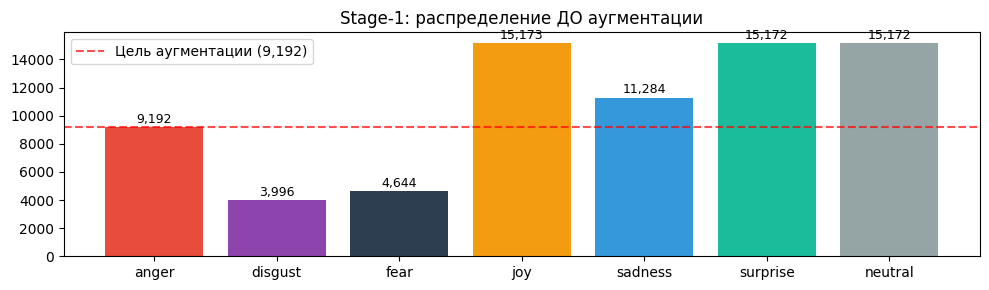

In [9]:
EMOTION_COLORS = {
    'anger':'#e74c3c','disgust':'#8e44ad','fear':'#2c3e50',
    'joy':'#f39c12','sadness':'#3498db','surprise':'#1abc9c','neutral':'#95a5a6',
}

df = stage1_ds['train'].to_pandas()
counts = df['label'].value_counts().sort_index()
total = len(df)

print('Распределение классов в Stage-1 train (ДО аугментации):')
for lid, cnt in counts.items():
    bar = '█' * int(cnt / total * 40)
    flag = '  ⚠ мало данных' if cnt < 3000 else ''
    print(f'  {EKMAN_ID2LABEL[lid]:<12}: {cnt:>7,}  ({cnt/total*100:4.1f}%)  {bar}{flag}')

fig, ax = plt.subplots(figsize=(10, 3))
labels_plot = [EKMAN_ID2LABEL[i] for i in counts.index]
bars = ax.bar(labels_plot, counts.values, color=[EMOTION_COLORS[l] for l in labels_plot])
ax.axhline(AUG_TARGET_S1, color='red', linestyle='--', alpha=0.7, label=f'Цель аугментации ({AUG_TARGET_S1:,})')
for bar, cnt in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f'{cnt:,}',
            ha='center', va='bottom', fontsize=9)
ax.set_title('Stage-1: распределение ДО аугментации')
ax.legend()
plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/distribution_before_aug.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Аугментация Stage-1 (редкие классы)

Парафраз через `cointegrated/rut5-base-paraphraser` + обратный перевод `Helsinki-NLP RU→EN→RU`.
Аугментируются только классы ниже порога `AUG_TARGET_S1`.

> Ориентировочное время на T4: ~10–20 мин при `method='both'`.  
> Если нужно быстрее — установи `AUG_METHOD_S1 = 'backtranslation'` (~5 мин) или `USE_AUGMENTATION = False`.

Аугментация Stage-1 (метод=both, цель=9192/класс)...
  anger       :  9192  ≥ 9192 — skip
  disgust     :  3996  → need +5196  (2 variants/text)
  Loading cointegrated/rut5-base-paraphraser...


config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/315 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/828k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

...

    → added 5196 augmented examples (generated 11689 valid)
  fear        :  4644  → need +4548  (1 variants/text)
    → added 4548 augmented examples (generated 8964 valid)
  joy         : 15173  ≥ 9192 — skip
  sadness     : 11284  ≥ 9192 — skip
  surprise    : 15172  ≥ 9192 — skip
  neutral     : 15172  ≥ 9192 — skip

Total added: 9744 examples
New training distribution:
  anger       :  9,192
  disgust     :  9,192
  fear        :  9,192
  joy         : 15,173
  sadness     : 11,284
  surprise    : 15,172
  neutral     : 15,172


Saving the dataset (0/1 shards):   0%|          | 0/84377 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/13171 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/15495 [00:00<?, ? examples/s]

Stage-1 augmented сохранён: /kaggle/working/stage1_data_augmented


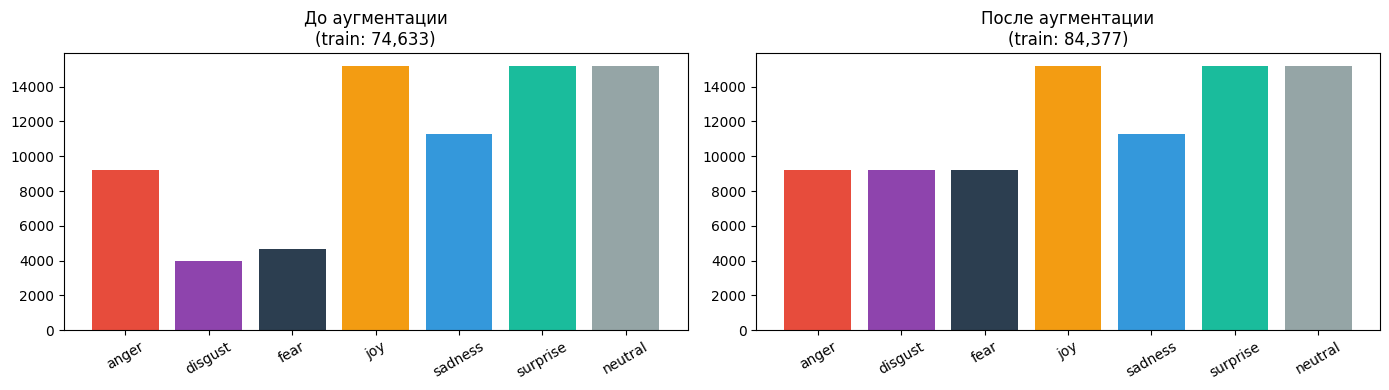


Сравнение Stage-1:
  Класс               До     После        Δ
  --------------------------------------------
  anger            9,192     9,192  +    0
  disgust          3,996     9,192  +5,196 ← добавлено
  fear             4,644     9,192  +4,548 ← добавлено
  joy             15,173    15,173  +    0
  sadness         11,284    11,284  +    0
  surprise        15,172    15,172  +    0
  neutral         15,172    15,172  +    0


In [10]:
from src.augmentation import augment_rare_classes

if not USE_AUGMENTATION:
    print('Аугментация отключена (USE_AUGMENTATION=False). Используем оригинальный Stage-1.')
    stage1_aug_ds = stage1_ds

elif os.path.exists(S1_AUG_DATA_PATH):
    print('Загружаем готовый аугментированный Stage-1 с диска...')
    stage1_aug_ds = load_from_disk(S1_AUG_DATA_PATH)

else:
    print(f'Аугментация Stage-1 (метод={AUG_METHOD_S1}, цель={AUG_TARGET_S1}/класс)...')
    stage1_aug_ds = augment_rare_classes(
        dataset=stage1_ds,
        label_names=LABEL_NAMES,
        target_per_class=AUG_TARGET_S1,
        method=AUG_METHOD_S1,
        n_variants=AUG_N_VARIANTS,
        batch_size=AUG_BATCH_SIZE,
        seed=SEED,
    )
    stage1_aug_ds.save_to_disk(S1_AUG_DATA_PATH)
    print(f'Stage-1 augmented сохранён: {S1_AUG_DATA_PATH}')

# Визуализация до/после
df_before = stage1_ds['train'].to_pandas()
df_after  = stage1_aug_ds['train'].to_pandas()
c_before  = df_before['label'].value_counts().sort_index()
c_after   = df_after['label'].value_counts().sort_index()

if USE_AUGMENTATION:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, (counts, title) in zip(axes, [(c_before, 'До аугментации'), (c_after, 'После аугментации')]):
        labels = [EKMAN_ID2LABEL[i] for i in counts.index]
        ax.bar(labels, counts.values, color=[EMOTION_COLORS[l] for l in labels])
        ax.set_title(f'{title}\n(train: {counts.sum():,})')
        ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig(f'{WORKING_DIR}/s1_augmentation.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nСравнение Stage-1:')
    print(f'  {"Класс":<12}  {"До":>8}  {"После":>8}  {"Δ":>7}')
    print('  ' + '-' * 44)
    for lid in range(NUM_LABELS):
        before = c_before.get(lid, 0)
        after  = c_after.get(lid, 0)
        delta  = after - before
        flag   = ' ← добавлено' if delta > 0 else ''
        print(f'  {LABEL_NAMES[lid]:<12}  {before:>8,}  {after:>8,}  +{delta:>5,}{flag}')
else:
    labels = [EKMAN_ID2LABEL[i] for i in c_before.index]
    plt.figure(figsize=(9, 3))
    plt.bar(labels, c_before.values, color=[EMOTION_COLORS[l] for l in labels])
    plt.title(f'Stage-1 train: {c_before.sum():,} примеров')
    plt.tight_layout(); plt.show()

## 5. Загрузка Stage-2 (чистый нативный корпус)

In [11]:
from src.data_loader import load_stage2_clean

if os.path.exists(S2_DATA_PATH):
    print('Загружаем готовый Stage-2 датасет с диска...')
    stage2_ds = load_from_disk(S2_DATA_PATH)
else:
    print('Собираем Stage-2 (чистый) датасет...')
    # cedr_m7 заменяет base cedr — те же тексты + disgust и neutral
    stage2_ds = load_stage2_clean(
        use_cedr=False, use_cedr_m7=True,
        use_brighter_hf=True, use_aniemore=True,
        seed=SEED,
    )
    stage2_ds = stage2_ds.map(
        lambda b: preprocess_batch(b, clean=True), batched=True, batch_size=500
    )
    stage2_ds.save_to_disk(S2_DATA_PATH)
    print(f'Stage-2 сохранён: {S2_DATA_PATH}')

print('\nStage-2 splits:')
for split in stage2_ds:
    print(f'  {split:12s}: {len(stage2_ds[split]):,}')

print('\nПокрытие классов в Stage-2 train:')
df2 = stage2_ds['train'].to_pandas()
total2 = len(df2)
for lid in range(NUM_LABELS):
    cnt = (df2['label'] == lid).sum()
    print(f'  {EKMAN_ID2LABEL[lid]:<12}: {cnt:>5,}  ({cnt/total2*100:.1f}%)')

Собираем Stage-2 (чистый) датасет...
Loading Aniemore/cedr-m7...
  columns: text='text', label='labels'  feat=List  sample=['neutral']
  → 11,292 examples (cedr-m7, 7 classes, native RU)
Loading brighter-dataset/BRIGHTER-emotion-categories (rus)...
  → 5,077 examples (BRIGHTER, native RU, 6 classes)
  Loading Aniemore/resd_annotated...
  → 1,675 examples (Aniemore/resd_annotated, native RU, 7 classes)

Merging datasets...
  cedr_m7: 11,292 examples
  brighter_hf: 5,077 examples
  aniemore: 1,675 examples

Deduplication: 18,044 → 14,624 (удалено 3,420 дублей)

Total before split: 14,624
Label distribution:
  anger       :  1,403  (9.6%)
  disgust     :    625  (4.3%)
  fear        :  1,403  (9.6%)
  joy         :  3,819  (26.1%)
  sadness     :  2,353  (16.1%)
  surprise    :    325  (2.2%)
  neutral     :  4,696  (32.1%)

Final splits:
  train       : 10,565
  validation  : 1,865
  test        : 2,194


Map:   0%|          | 0/10565 [00:00<?, ? examples/s]

Map:   0%|          | 0/1865 [00:00<?, ? examples/s]

Map:   0%|          | 0/2194 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/10565 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1865 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2194 [00:00<?, ? examples/s]

Stage-2 сохранён: /kaggle/working/stage2_data

Stage-2 splits:
  train       : 10,565
  validation  : 1,865
  test        : 2,194

Покрытие классов в Stage-2 train:
  anger       : 1,014  (9.6%)
  disgust     :   451  (4.3%)
  fear        : 1,014  (9.6%)
  joy         : 2,759  (26.1%)
  sadness     : 1,700  (16.1%)
  surprise    :   235  (2.2%)
  neutral     : 3,392  (32.1%)


## 6. Аугментация Stage-2

In [16]:
if not USE_AUGMENTATION:
    print('Аугментация отключена. Используем оригинальный Stage-2.')
    stage2_aug_ds = stage2_ds

# elif os.path.exists(S2_AUG_DATA_PATH):
#     print('Загружаем готовый аугментированный Stage-2 с диска...')
#     stage2_aug_ds = load_from_disk(S2_AUG_DATA_PATH)

else:
    print(f'Аугментация Stage-2 (метод={AUG_METHOD_S2}, цель={AUG_TARGET_S2}/класс)...')
    stage2_aug_ds = augment_rare_classes(
        dataset=stage2_ds,
        label_names=LABEL_NAMES,
        target_per_class=AUG_TARGET_S2,
        method=AUG_METHOD_S2,
        n_variants=AUG_N_VARIANTS_S2,
        batch_size=AUG_BATCH_SIZE,
        seed=SEED,
    )
    stage2_aug_ds.save_to_disk(S2_AUG_DATA_PATH)
    print(f'Stage-2 augmented сохранён: {S2_AUG_DATA_PATH}')

print('\nStage-2 (финальный для обучения):')
df2a = stage2_aug_ds['train'].to_pandas()
total2a = len(df2a)
for lid in range(NUM_LABELS):
    cnt = (df2a['label'] == lid).sum()
    flag = '' if cnt >= AUG_TARGET_S2 else '  ← мало данных!'
    print(f'  {EKMAN_ID2LABEL[lid]:<12}: {cnt:>5,}  ({cnt/total2a*100:.1f}%){flag}')

Аугментация Stage-2 (метод=backtranslation, цель=1000/класс)...
  anger       :  1014  ≥ 1000 — skip
  disgust     :   451  → need +549  (2 variants/text)
  Loading Helsinki-NLP/opus-mt-ru-en and opus-mt-en-ru...


/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

...

    → added 436 augmented examples (generated 436 valid)
  fear        :  1014  ≥ 1000 — skip
  joy         :  2759  ≥ 1000 — skip
  sadness     :  1700  ≥ 1000 — skip
  surprise    :   235  → need +765  (4 variants/text)
    → added 183 augmented examples (generated 183 valid)
  neutral     :  3392  ≥ 1000 — skip

Total added: 619 examples
New training distribution:
  anger       :  1,014
  disgust     :    887
  fear        :  1,014
  joy         :  2,759
  sadness     :  1,700
  surprise    :    418
  neutral     :  3,392


Saving the dataset (0/1 shards):   0%|          | 0/11184 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1865 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2194 [00:00<?, ? examples/s]

Stage-2 augmented сохранён: /kaggle/working/stage2_data_augmented

Stage-2 (финальный для обучения):
  anger       : 1,014  (9.1%)
  disgust     :   887  (7.9%)  ← мало данных!
  fear        : 1,014  (9.1%)
  joy         : 2,759  (24.7%)
  sadness     : 1,700  (15.2%)
  surprise    :   418  (3.7%)  ← мало данных!
  neutral     : 3,392  (30.3%)


## Итог

Данные подготовлены и сохранены на диск.

| Датасет | Путь | Описание |
|---|---|---|
| Stage-1 raw | `stage1_data/` | До аугментации |
| Stage-1 aug | `stage1_data_augmented/` | После аугментации |
| Stage-2 raw | `stage2_data/` | Чистый нативный RU |
| Stage-2 aug | `stage2_data_augmented/` | После аугментации |

**Следующий шаг:** запустить `02_training.ipynb`